In [1]:
import os
import pandas as pd
import swifter 
import numpy as np
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split


nltk_path = os.path.join(os.path.dirname(nltk.__file__), 'nltk_data')
nltk.data.path.append(nltk_path)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

force_prep = False # set to True if we want to preprocess data by force

if os.path.exists('prepped_articles.csv') and not force_prep:
    df = df = pd.read_csv('prepped_articles.csv')
    X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.2, random_state=42)
else:
    df = pd.read_csv('articles.csv')

    X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.2, random_state=42)

    stop_words = set(stopwords.words('english'))
    def preprocess(txt):
        txt = txt.lower()
        txt = ''.join([c for c in txt if c not in string.punctuation])
        toks = word_tokenize(txt)
        toks = [word for word in toks if word not in stop_words]
        return ' '.join(toks)

    X_train = X_train.swifter.apply(preprocess)
    X_test = X_test.swifter.apply(preprocess)

    df_prepped = pd.DataFrame({'text': pd.concat([X_train, X_test]), 'label': pd.concat([y_train, y_test])})
    df_prepped.to_csv('prepped_articles.csv', index=False)
X_train
X_test

[nltk_data] Downloading package stopwords to /home/alex/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/alex/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/alex/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


6480     justice departments decision water recommendat...
431      white house press secretary sarah huckabee san...
12412    new york ap — embarrassing aboutface new york ...
836      president trump issued two executive orders la...
13032    west palm beach florida cnnpresident donald tr...
                               ...                        
4844     congress wednesdays protest dramatic escalatio...
7677     people list best news stories 2020 would extre...
12276    partisan enmity incendiary rhetoric polarizati...
3559     shanghai—family friends rushed hospitals thurs...
7040     like father former rep ron paul sen rand paul ...
Name: text, Length: 3473, dtype: object

In [2]:
from keras._tf_keras.keras.preprocessing.text import Tokenizer
from keras._tf_keras.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)
X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)

max_length = 100
X_train = pad_sequences(X_train, maxlen=max_length, padding='post')
X_test = pad_sequences(X_test, maxlen=max_length, padding='post')

2025-09-24 03:33:29.494521: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-24 03:33:29.515368: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758656009.535835   40789 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758656009.540490   40789 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1758656009.556352   40789 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
# Load GloVe
embeddings_index = {}
with open('glove/glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f'Found {len(embeddings_index)} word vectors.')


Found 400000 word vectors.


In [4]:
# Prepare embedding matrix
embedding_dim = 100
word_index = tokenizer.word_index
num_words = len(word_index) + 1
embedding_matrix = np.zeros((num_words, embedding_dim))

for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [5]:
import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
        print('Using GPU:', gpus[0])
    except RuntimeError as e:
        print(e)
else:
    print('GPU Not found')

GPU Not found


2025-09-24 03:33:58.589317: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (100)


In [ ]:
from keras._tf_keras.keras.models import Sequential
from keras._tf_keras.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from keras._tf_keras.keras.optimizers import Adam
from keras._tf_keras.keras.regularizers import l2

# Clear previous models and free memory
import gc
tf.keras.backend.clear_session()
gc.collect()

model = Sequential()

# GloVe-based Embedding layer
model.add(Embedding(
    input_dim=num_words,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=False   # keep GloVe fixed initially
))

# First Bidirectional LSTM layer 
model.add(Bidirectional(LSTM(64, dropout=0.1, recurrent_dropout=0.1, return_sequences=True)))

# Second Bidirectional LSTM layer 
model.add(Bidirectional(LSTM(64, dropout=0.1, recurrent_dropout=0.1)))

# Fully connected layers
model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dropout(0.1))

# Template for 1-layer LSTM
# model.add(Bidirectional(LSTM(32, dropout=0.1, recurrent_dropout=0.1)))
# model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))
# model.add(Dropout(0.1))

# Output layer
model.add(Dense(3, activation='softmax'))


In [7]:
from keras._tf_keras.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss',
                           patience=2,  # how many epochs with no improvement before stopping
                           restore_best_weights=True)

In [ ]:
import keras._tf_keras.keras.backend as keras_backend
class_weights = {
    0: 1.0,  
    1: 2.0,  
    2: 1.5   
}

gc.collect()  
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(np.array(X_train), np.array(y_train), epochs=10, batch_size=32, class_weight=class_weights, validation_data=(X_test, y_test), callbacks=[early_stop])
gc.collect()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │    23,252,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,252,300 (88.70 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,252,300 (88.70 MB)

None
Epoch 1/10
435/435 ━━━━━━━━━━━━━━━━━━━━ 72s 147ms/step - accuracy: 0.4770 - loss: 1.7741 - val_accuracy: 0.5655 - val_loss: 0.9139
Epoch 2/10
435/435 ━━━━━━━━━━━━━━━━━━━━ 66s 152ms/step - accuracy: 0.5812 - loss: 1.1852 - val_accuracy: 0.6297 - val_loss: 0.8224
Epoch 3/10
435/435 ━━━━━━━━━━━━━━━━━━━━ 76s 175ms/step - accuracy: 0.6439 - loss: 1.0771 - val_accuracy: 0.6401 - val_loss: 0.7857
Epoch 4/10
435/435 ━━━━━━━━━━━━━━━━━━━━ 69s 158ms/step - accuracy: 0.6544 - loss: 1.0165 - val_accuracy: 0.6628 - val_loss: 0.7503
Epoch 5/10
435/435 ━━━━━━━━━━━━━━━━━━━━ 68s 157ms/step - accuracy: 0.6715 - loss: 0.9768 - val_accuracy: 0.6153 - val_loss: 0.7608
Epoch 6/10
435/435 ━━━━━━━━━━━━━━━━━━━━ 68s 157ms/step - accuracy: 0.6805 - loss: 0.9538 - val_accuracy: 0.6240 - val_loss: 0.7668


740

109/109 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step
Accuracy: 0.6628
Precision: 0.6712
Recall: 0.6628
F1 Score: 0.6563

Confusion Matrix:
[[1247  116  167]
 [ 251  467   96]
 [ 471   70  588]]


382

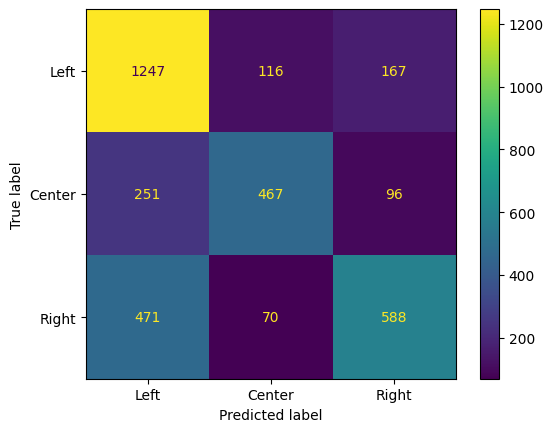

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Compute evaluation metrics
print(f'Accuracy: {accuracy_score(y_test, y_pred_classes):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_classes, average='weighted'):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_classes, average='weighted'):.4f}')
print(f'F1 Score: {f1_score(y_test, y_pred_classes, average='weighted'):.4f}')

# Show confusion matrix
print('\nConfusion Matrix:')
conf_matrix = confusion_matrix(y_test, y_pred_classes)
print(conf_matrix)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Left', 'Center', 'Right'])
disp.plot()
gc.collect()


In [10]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │    23,252,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 128)       │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,827,543 (90.89 MB)

 Trainable params: 191,747 (749.01 KB)

 Non-trainable params: 23,252,300 (88.70 MB)

 Optimizer params: 383,496 (1.46 MB)

None


In [ ]:
# Save the full model
model.save('glove_LSTMRNN_64-64.keras')